<a href="https://colab.research.google.com/github/reenasharon05/TCSiON-Course/blob/main/modeltraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pwd

'/content'

<ipython-input-6-f9b426a5fead>:123: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, ax=ax,cmap='plasma').set(


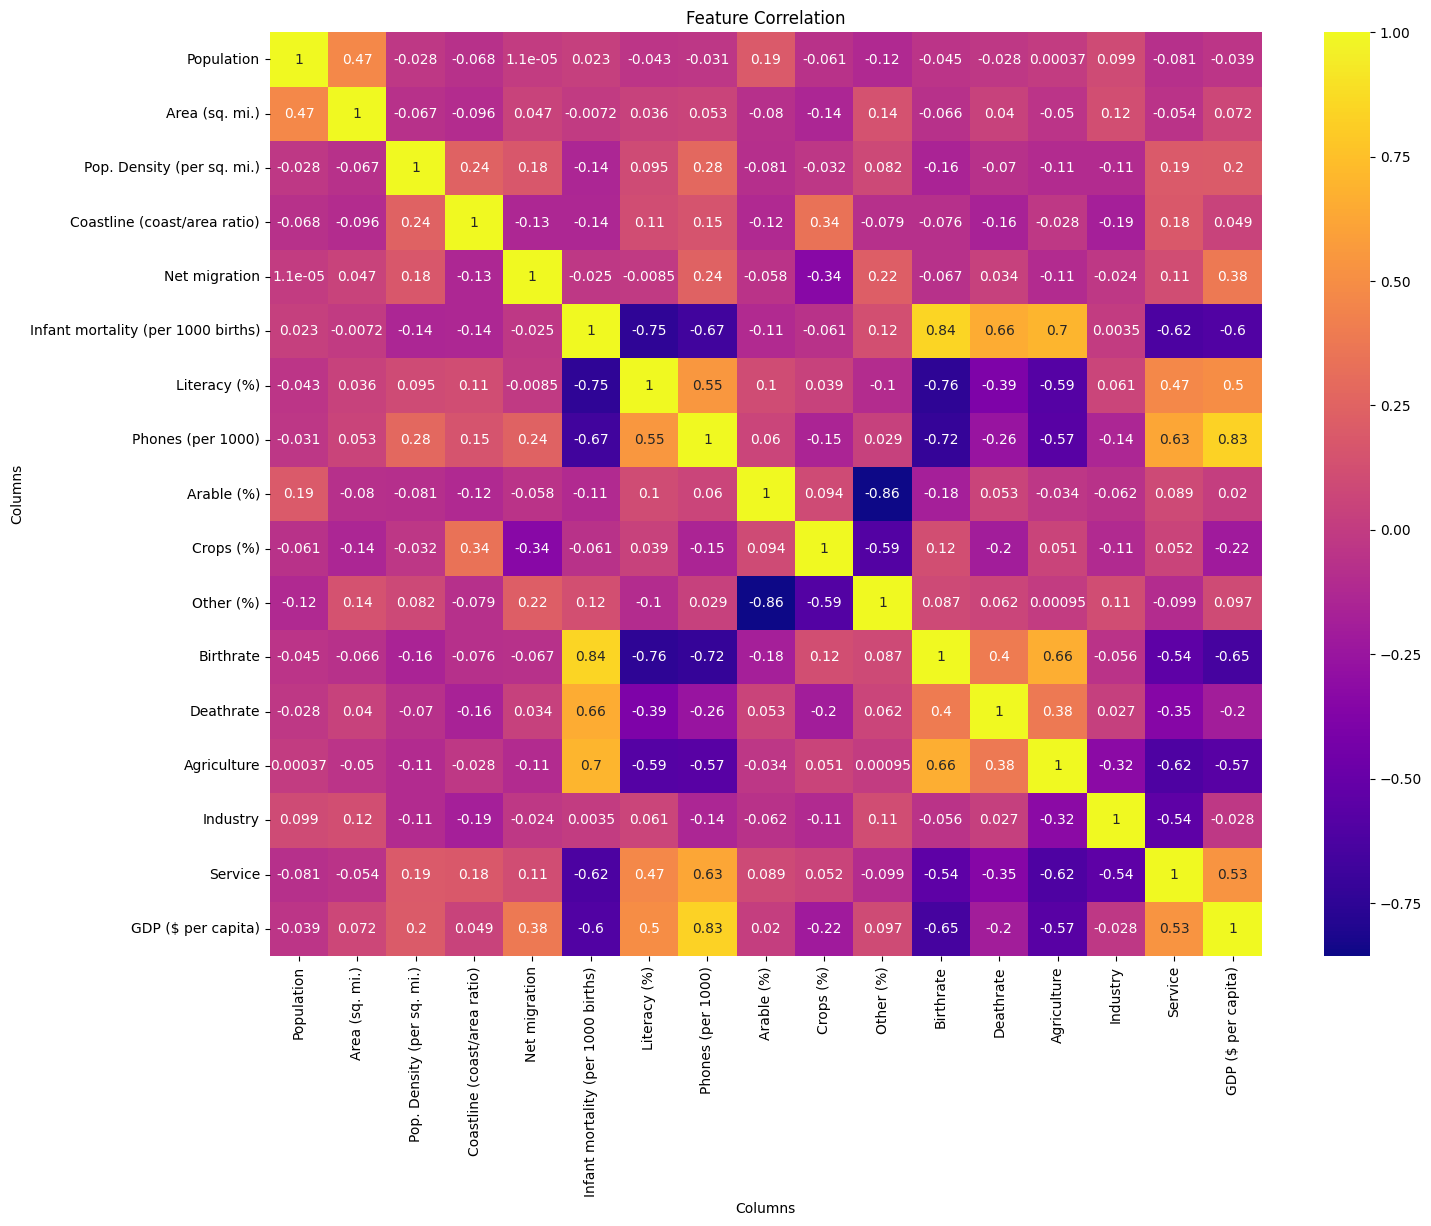

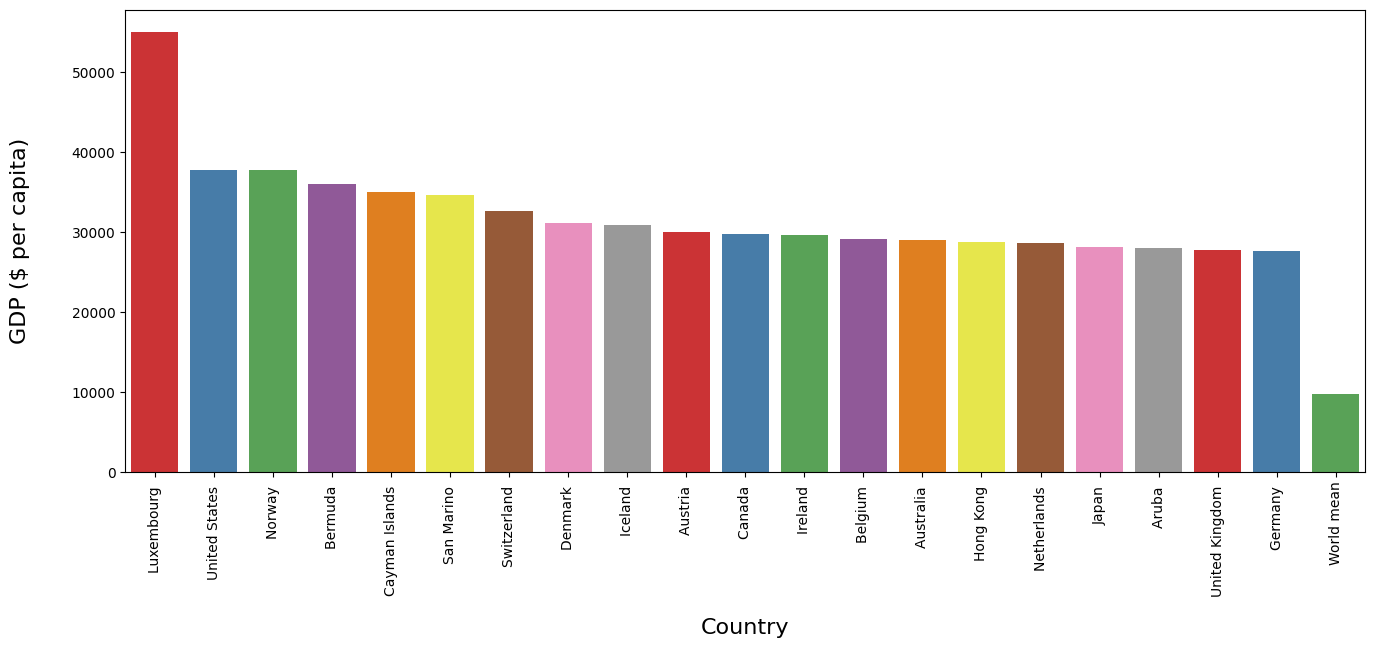

<ipython-input-6-f9b426a5fead>:152: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  corr_to_gdp = pd.Series()


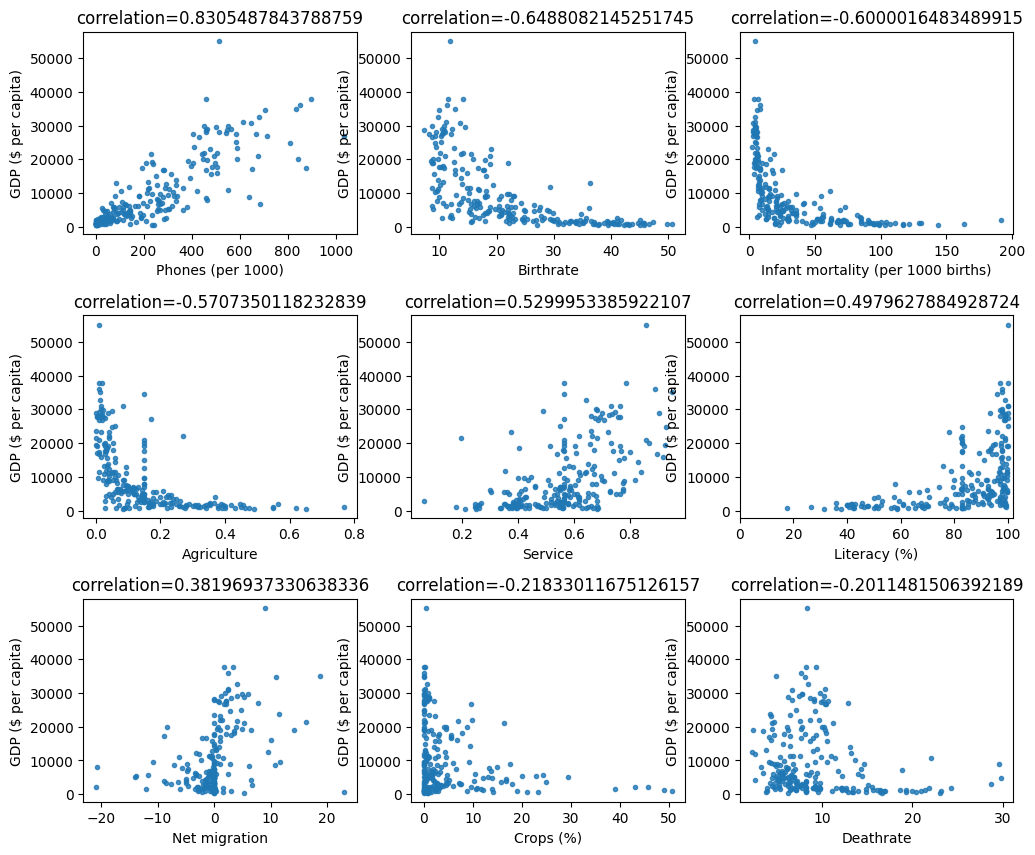

181
181
rmse_train1: 5056.649025268029 msle_train1: 4.7516224980376744
rmse_test1: 4848.092672149603 msle_test1: 2.7747074770098608
R2_Score:  70.36869992055341
RMSE_train :  5191.437392786857
RMSE_test :  4943.61989170278
R2_Score:  69.27834066698153
rmse_train: 3501.3357906121314 msle_train: 0.18940263345626432
rmse_test: 4169.187227836337 msle_test: 0.5579248655334688
R2_Score:  78.14970401872591
Fitting 5 folds for each of 343 candidates, totalling 1715 fits
[CV] END ........................max_depth=3, n_estimators=1; total time=   0.0s
[CV] END ........................max_depth=3, n_estimators=1; total time=   0.0s
[CV] END ........................max_depth=3, n_estimators=1; total time=   0.0s
[CV] END ........................max_depth=3, n_estimators=1; total time=   0.0s
[CV] END ........................max_depth=3, n_estimators=1; total time=   0.0s
[CV] END ........................max_depth=3, n_estimators=2; total time=   0.0s
[CV] END ........................max_depth=3, n

Text(0, 0.5, 'Root mean squared error')

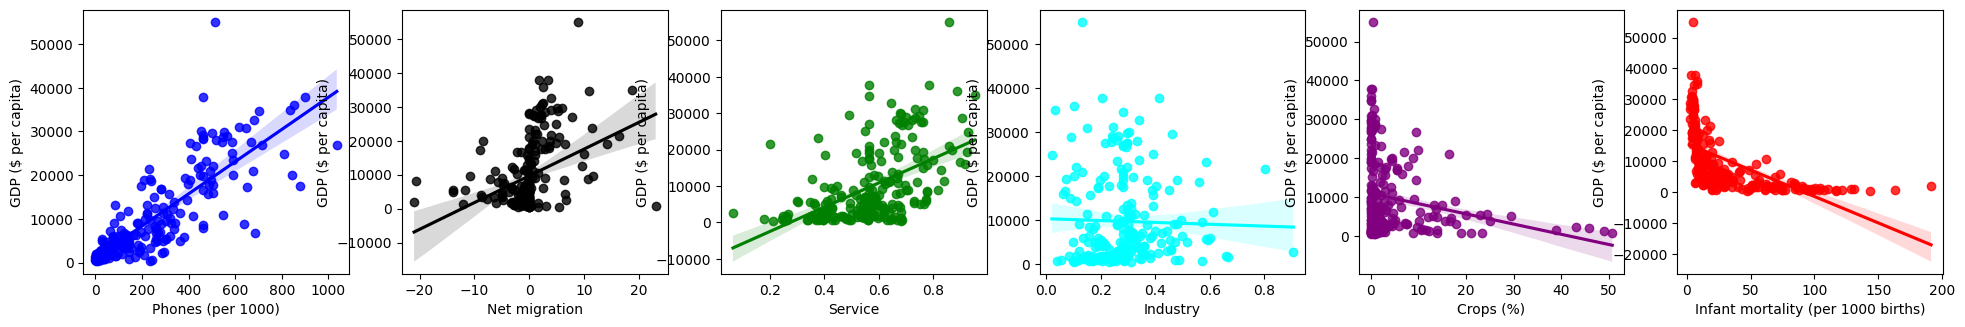

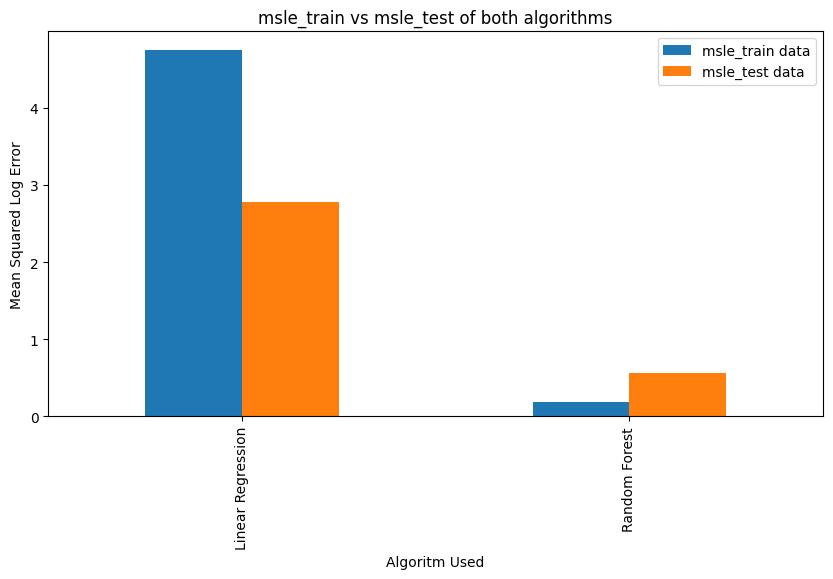

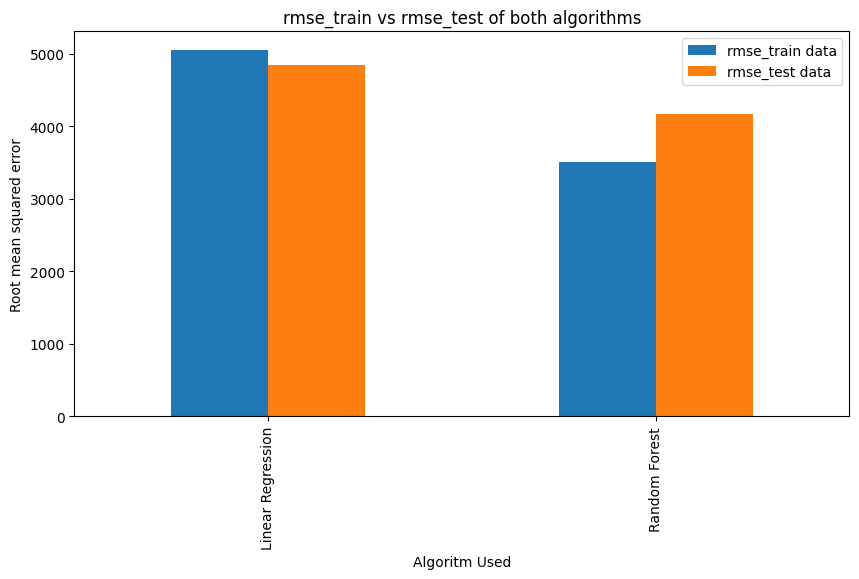

In [ ]:

#!/usr/bin/env python
# coding: utf-8

# In[1]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
#Importing Important Libraries
import seaborn as sns # Used for visualization
import matplotlib.pyplot as plt # Used for visualization
get_ipython().run_line_magic('matplotlib', 'inline')

#sklearns used to build the models
from sklearn.preprocessing import LabelEncoder #Label encoder is used to work with categorical data
from sklearn.model_selection import train_test_split,GridSearchCV # Used for splittng the dataset into training and testing
from sklearn.linear_model import LinearRegression,ElasticNet #Library for linear regresion
from sklearn.ensemble import RandomForestRegressor #Library for Random Forest Regression
from sklearn.metrics import mean_squared_error, mean_squared_log_error #Libraries to fing mean squared error
from sklearn.metrics import r2_score #Library to predict the accuracy of model


# In[2]:


#Reading the data set
df=pd.read_csv('gdpWorld.csv')
df.head


# In[3]:


#Checking the data type of each column
df.dtypes


# In[4]:


#Since most of the data is in object ,we will convert it into float 64 by removing the (,) and replacing it with (.)
df.replace(',','.',regex=True, inplace=True)
df.head()


# In[5]:


#Converting the columns into float64
df = df.astype({'Net migration': 'float64', 'Infant mortality (per 1000 births)': 'float64', 'Literacy (%)': 'float64',
                   'Phones (per 1000)': 'float64', 'Arable (%)': 'float64', 'Crops (%)': 'float64', 'Other (%)': 'float64',
                   'Birthrate': 'float64', 'Deathrate': 'float64', 'Agriculture': 'float64',
                    'Industry': 'float64', 'Service': 'float64','Pop. Density (per sq. mi.)':'float64','Coastline (coast/area ratio)':'float64'})


# In[6]:


#Checking the data types again
df.dtypes


# In[7]:


#Checking for null values in the dataset
df.isnull().sum()


# In[8]:


#Here we are going to fill the null values with appropriate methods
#mean():For integer and float values
#mode():For Categorical data
#median():Can be used for both
df['Literacy (%)'].fillna(df['Literacy (%)'].mean(),inplace=True)
df['GDP ($ per capita)'].fillna(df['GDP ($ per capita)'].mean(),inplace=True)
df['Agriculture'].fillna(df['Agriculture'].mean(),inplace=True)
df['Industry'].fillna(df['Industry'].mean(),inplace=True)
df['Service'].fillna(df['Service'].mean(),inplace=True)
df['Birthrate'].fillna(df['Birthrate'].mean(),inplace=True)
df['Deathrate'].fillna(df['Deathrate'].mean(),inplace=True)
df['Phones (per 1000)'].fillna(df['Phones (per 1000)'].mean(),inplace=True)
df['Arable (%)'].fillna(df['Arable (%)'].mean(),inplace=True)
df['Crops (%)'].fillna(df['Crops (%)'].mean(),inplace=True)
df['Other (%)'].fillna(df['Other (%)'].mean(),inplace=True)
df['Pop. Density (per sq. mi.)'].fillna(df['Pop. Density (per sq. mi.)'].mean(),inplace=True)
df['Coastline (coast/area ratio)'].fillna(df['Coastline (coast/area ratio)'].mean(),inplace=True)
df['Net migration'].fillna(df['Net migration'].mean(),inplace=True)
df['Infant mortality (per 1000 births)'].fillna(df['Infant mortality (per 1000 births)'].mean(),inplace=True)


# In[9]:


#Since Climate is categorical we are using mode
df['Climate'].fillna(df['Climate'].mode,inplace=True)


# In[10]:


#Validating
df.isnull().sum()


# In[11]:


#We are moving the column (GDP ($ per capita)) to the end of the data set as it is our target variable
first_column=df.pop('GDP ($ per capita)')
df.insert(19,'GDP ($ per capita)',first_column)
df


# In[12]:


#Using the Heatmap to find columns that are closely related to GDP
#If the number is close to one then the columns are highly related
fig, ax = plt.subplots(figsize=(16,12))
sns.heatmap(df.corr(), annot=True, ax=ax,cmap='plasma').set(
    title = 'Feature Correlation', xlabel = 'Columns', ylabel = 'Columns')
plt.show()


# In[13]:


#Plotting the countries with highest contribution to gdp
fig, ax = plt.subplots(figsize=(16,6))
top_gdp_countries = df.sort_values('GDP ($ per capita)',ascending=False).head(20)
mean = pd.DataFrame({'Country':['World mean'], 'GDP ($ per capita)':[df['GDP ($ per capita)'].mean()]})
gdps = pd.concat([top_gdp_countries[['Country','GDP ($ per capita)']],mean],ignore_index=True)
sns.barplot(x='Country', y='GDP ($ per capita)', data=gdps, palette='Set1')
ax.set_xlabel(ax.get_xlabel(), labelpad=15)
ax.set_ylabel(ax.get_ylabel(), labelpad=30)
ax.xaxis.label.set_fontsize(16)
ax.yaxis.label.set_fontsize(16)
plt.xticks(rotation=90)
plt.show()


# In[14]:


#This is a scatterplot to find the hishly co-related data with gdp
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12,10))
plt.subplots_adjust(hspace=0.4)

corr_to_gdp = pd.Series()
for col in df.columns.values[2:]:
    if ((col!='GDP ($ per capita)')&(col!='Climate')):
        corr_to_gdp[col] = df['GDP ($ per capita)'].corr(df[col])
abs_corr_to_gdp = corr_to_gdp.abs().sort_values(ascending=False)
corr_to_gdp = corr_to_gdp.loc[abs_corr_to_gdp.index]

for i in range(3):
    for j in range(3):
        sns.regplot(x=corr_to_gdp.index.values[i*3+j], y='GDP ($ per capita)', data=df,
                   ax=axes[i,j], fit_reg=False, marker='.')
        title = 'correlation='+str(corr_to_gdp[i*3+j])
        axes[i,j].set_title(title)
axes[1,2].set_xlim(0,102)
plt.show()


# In[15]:


#Using Seaborn library regplot to plot the regression line with respect to gdp
plt.figure(figsize=(24,24))
plt.subplot(6,6,1)
sns.regplot(x='Phones (per 1000)',y='GDP ($ per capita)',data=df,color='blue')

plt.subplot(6,6,2)
sns.regplot(x='Net migration',y='GDP ($ per capita)',data=df,color='black')

plt.subplot(6,6,3)
sns.regplot(x='Service',y='GDP ($ per capita)',data=df,color='green')

plt.subplot(6,6,4)
sns.regplot(x='Industry',y='GDP ($ per capita)',data=df,color='cyan')

plt.subplot(6,6,5)
sns.regplot(x='Crops (%)',y='GDP ($ per capita)',data=df,color='purple')

plt.subplot(6,6,6)
sns.regplot(x=df['Infant mortality (per 1000 births)'],y='GDP ($ per capita)',data=df,color='red')


# In[16]:


train, test = train_test_split(df, test_size=0.2)
training_features = [
    'Phones (per 1000)','Net migration','Service',
    'Industry','Crops (%)','Infant mortality (per 1000 births)'
       ]
target = 'GDP ($ per capita)'
train_X = train[training_features]
train_Y = train[target]
test_X = test[training_features]
test_Y = test[target]

print(len(train_Y))
print(len(train_X))


# In[18]:


#Building the Linear Regression Model
model = LinearRegression()
model.fit(train_X, train_Y)
LinearRegression()


# In[19]:


train_pred_Y = model.predict(train_X)
test_pred_Y = model.predict(test_X)
train_pred_Y = pd.Series(train_pred_Y.clip(0, train_pred_Y.max()), index=train_Y.index)
test_pred_Y = pd.Series(test_pred_Y.clip(0, test_pred_Y.max()), index=test_Y.index)

#This will be used by the r2_score library to predict the accuracy of the model
score=model.predict(test_X)


#This all is used for finding rmse and msle
rmse_train1 = np.sqrt(mean_squared_error(train_pred_Y, train_Y))
msle_train1 = mean_squared_log_error(train_pred_Y, train_Y)
rmse_test1 = np.sqrt(mean_squared_error(test_pred_Y, test_Y))
msle_test1 = mean_squared_log_error(test_pred_Y, test_Y)

print('rmse_train1:',rmse_train1,'msle_train1:',msle_train1)
print('rmse_test1:',rmse_test1,'msle_test1:',msle_test1)
print('R2_Score: ', r2_score(test_Y,score)*100)


# ## The accuracy of the linear regression model is 78%. let's do the hyper tuning to make better model.
#

# In[20]:


#Using ElasticNet for hyperparameter tuning
ELS=ElasticNet(random_state=42)
ELS.fit(train_X,train_Y)


# In[21]:


train_pred = ELS.predict(train_X)
test_pred = ELS.predict(test_X)
rmse_trainh = mean_squared_error(train_pred,train_Y,squared=False)
rmse_testh = mean_squared_error(test_pred, test_Y,squared=False)
score1=ELS.predict(test_X)

print("RMSE_train : ",rmse_trainh)
print("RMSE_test : ",rmse_testh)
print('R2_Score: ', r2_score(test_Y,score1)*100)


# ### The Accuracy of the linear regression model after hypertuning is also 78% with little no effect. so we compare this model with random forest regression

# In[22]:


#Using RandomForestRegressor with the given parameters
model = RandomForestRegressor(n_estimators = 200,
                             max_depth = 8,
                             min_weight_fraction_leaf = 0.05,
                             max_features = 0.8,
                             random_state = 42)
model.fit(train_X, train_Y)


# In[23]:


train_pred_Y = model.predict(train_X)
#The model Preperation is only required until this line.
#The further lines are just to find the root mean sqaured error and mean squared log error.
#Note that this step is not important can can be skipped until it is told to find

test_pred_Y = model.predict(test_X)
train_pred_Y = pd.Series(train_pred_Y.clip(0, train_pred_Y.max()), index=train_Y.index)
test_pred_Y = pd.Series(test_pred_Y.clip(0, test_pred_Y.max()), index=test_Y.index)

#This will be used by the r2_score library to predict the accuracy of the model
score2=model.predict(test_X)

#This all is used for finding rmse and msle
rmse_train = np.sqrt(mean_squared_error(train_pred_Y, train_Y))
msle_train = mean_squared_log_error(train_pred_Y, train_Y)
rmse_test = np.sqrt(mean_squared_error(test_pred_Y, test_Y))
msle_test = mean_squared_log_error(test_pred_Y, test_Y)

print('rmse_train:',rmse_train,'msle_train:',msle_train)
print('rmse_test:',rmse_test,'msle_test:',msle_test)
print('R2_Score: ', r2_score(test_Y,score2)*100)


# ## The accuracy of random forest regeression is 89%. lets improve by hypertuning.

# In[24]:


# hyper parameter optimization Random Forest
op_model = RandomForestRegressor()
params = {'n_estimators':[x for x in range(1,50)], 'max_depth':[x for x in range(3,10)]}
grid_model = GridSearchCV(op_model, param_grid=params, verbose=2)
grid_model.fit(train_X,train_Y)


# In[25]:


#This will give us the best solution from the forest
grid_model.best_estimator_


# In[26]:


op_model = RandomForestRegressor(max_depth=9, n_estimators=24) #We will input the max_depth and n_estimators that we found from the above cell
op_model.fit(train_X,train_Y)
train_pred = op_model.predict(train_X)
test_pred = op_model.predict(test_X)
rmse_trainrh = mean_squared_error(train_pred, train_Y,squared=False)
rmse_testrh = mean_squared_error(test_pred, test_Y,squared=False)
score3=op_model.predict(test_X)

print("RMSE_train : ",rmse_trainrh)
print("RMSE_test : ",rmse_testrh)
print('R2_Score: ', r2_score(test_Y,score3)*100)


# In[27]:


#Comparing the rmse and msle of both algorithms
plotdata = pd.DataFrame({

    "msle_train data":[msle_train1,msle_train],

    "msle_test data":[msle_test1,msle_test]},

    index=[ "Linear Regression","Random Forest"])


plotdata.plot(kind="bar",figsize=(10, 5))

plt.title("msle_train vs msle_test of both algorithms")

plt.xlabel("Algoritm Used")

plt.ylabel("Mean Squared Log Error")

plotdata = pd.DataFrame({

    "rmse_train data":[rmse_train1,rmse_train],

    "rmse_test data":[rmse_test1,rmse_test]},

    index=[ "Linear Regression","Random Forest"])


plotdata.plot(kind="bar",figsize=(10, 5))

plt.title("rmse_train vs rmse_test of both algorithms")

plt.xlabel("Algoritm Used")

plt.ylabel("Root mean squared error")


# In[ ]:

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using the Heatmap to find columns that are closely related to GDP
# If the number is close to one then the columns are highly related
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, ax=ax, cmap='viridis').set(
    title='Feature Correlation', xlabel='Columns', ylabel='Columns')
plt.show()


<ipython-input-13-b95efb0fd53f>:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, ax=ax, cmap='viridis').set(
